# Hypothesis 3: iteration improves over a one-shot transformation

We sweep the number of Recursive Sketch iterations `T` while keeping one train/test split, the target dimension, and the downstream model fixed. Only the forest and projection seed changes between repetitions, making the comparison paired and reducing variation caused by changing datasets. `T=0` is the initial random projection, and `T=1` is the one-shot tree-path transformation.

In [1]:
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

import sys
import time
import numpy as np
from pathlib import Path

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, recursive_sketch, plot_critical_difference

Rule of thumb: p=120, d=20*p=2400


,mean_accuracy,std_accuracy,mean_wall,mean_cpu,n,se_accuracy,ci95_accuracy
T,,,,,,,
0,0.686,0.000,0.023,0.274,12,0.000,0.000
1,0.857,0.013,1.839,6.136,12,0.004,0.007
2,0.845,0.014,3.477,10.775,12,0.004,0.008
3,0.834,0.018,4.973,15.195,12,0.005,0.010


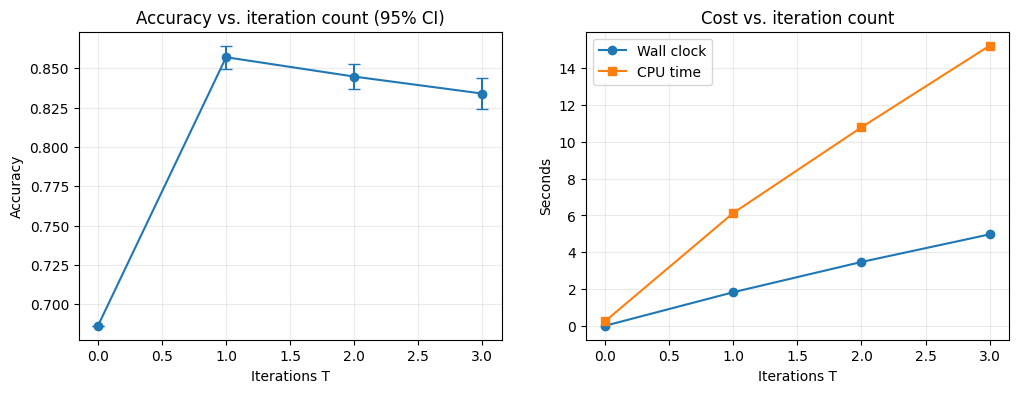

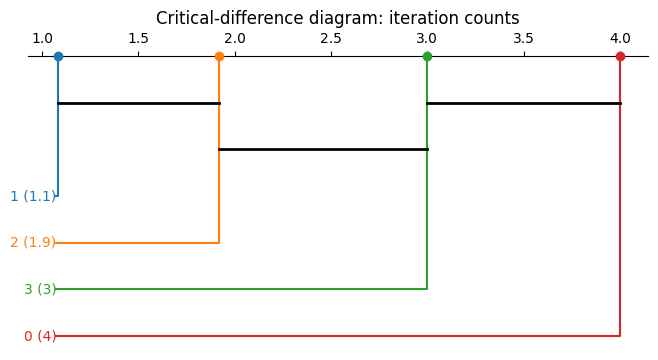

T,T2_minus_T1,T3_minus_T1
mean,-0.012,-0.023
std,0.009,0.012
count,12.000,12.000


Hypothesis 3: NOT SUPPORTED — paired T=2 minus T=1 accuracy gain=-0.012 (95% CI -0.018, -0.007); 12 model seeds on one fixed dataset
Total experiment wall-clock time: 143.9 seconds


In [2]:
MODEL_SEEDS = list(range(12))
DATA_SEED = 42
X_train, _, X_test, y_train, _, y_test = classification_data(DATA_SEED)
P = X_train.shape[1]
TARGET_DIMENSION = 20 * P
print(f'Rule of thumb: p={P}, d=20*p={TARGET_DIMENSION}')
experiment_start = time.perf_counter()
rows = []
for seed in MODEL_SEEDS:
    for iterations in [0, 1, 2, 3]:
        representation = recursive_sketch(seed, n_components=TARGET_DIMENSION, n_iterations=iterations)
        wall_start = time.perf_counter()
        cpu_start = time.process_time()
        X_train_view = representation.fit_transform(X_train, y_train)
        X_test_view = representation.transform(X_test)
        wall_seconds = time.perf_counter() - wall_start
        cpu_seconds = time.process_time() - cpu_start
        accuracy, errors = classification_score(
            downstream_classifier(seed), X_train_view, y_train, X_test_view, y_test
        )
        rows.append({'seed': seed, 'T': iterations, 'accuracy': accuracy, 'errors': errors, 'wall_seconds': wall_seconds, 'cpu_seconds': cpu_seconds})
results = pd.DataFrame(rows)
summary = results.groupby('T').agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_wall=('wall_seconds', 'mean'), mean_cpu=('cpu_seconds', 'mean'), n=('accuracy', 'size'))
summary['se_accuracy'] = summary.std_accuracy / np.sqrt(summary.n)
summary['ci95_accuracy'] = 1.96 * summary.se_accuracy
display(summary.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summary.index, summary.mean_accuracy, yerr=summary.ci95_accuracy, marker='o', capsize=4)
axes[0].set(xlabel='Iterations T', ylabel='Accuracy', title='Accuracy vs. iteration count (95% CI)')
axes[1].plot(summary.index, summary.mean_wall, marker='o', label='Wall clock')
axes[1].plot(summary.index, summary.mean_cpu, marker='s', label='CPU time')
axes[1].set(xlabel='Iterations T', ylabel='Seconds', title='Cost vs. iteration count')
axes[1].legend()
for axis in axes: axis.grid(alpha=0.25)
plt.show()
plot_critical_difference(
    results,
    block_column='seed',
    method_column='T',
    title='Critical-difference diagram: iteration counts',
)
plt.show()
paired = results.pivot(index='seed', columns='T', values='accuracy')
paired['T2_minus_T1'] = paired[2] - paired[1]
paired['T3_minus_T1'] = paired[3] - paired[1]
display(paired[['T2_minus_T1', 'T3_minus_T1']].agg(['mean', 'std', 'count']).round(3))
gain_values = paired['T2_minus_T1'].to_numpy()
gain = gain_values.mean()
gain_half_width = 1.96 * gain_values.std(ddof=1) / np.sqrt(gain_values.size)
if gain + gain_half_width < 0:
    verdict = 'NOT SUPPORTED'
elif gain - gain_half_width > 0:
    verdict = 'SUPPORTED'
else:
    verdict = 'INCONCLUSIVE'
print(f'Hypothesis 3: {verdict} — paired T=2 minus T=1 accuracy gain={gain:.3f} (95% CI {gain - gain_half_width:.3f}, {gain + gain_half_width:.3f}); 12 model seeds on one fixed dataset')
print(f'Total experiment wall-clock time: {time.perf_counter() - experiment_start:.1f} seconds')

## Conclusion

**Hypothesis:** reusing the compressed representation in later forest stages improves performance over a one-shot transformation.

**Experiment:** sweep `T` over 0, 1, 2, and 3 using 12 forest/projection seeds on one fixed difficult classification split, keeping `d=8192` and the downstream model fixed.

**Measure:** held-out accuracy and integer errors, with mean ± standard deviation in the table, 95% confidence intervals in the plot, paired accuracy differences from `T=1`, and fit-transform wall-clock and CPU time.

**Result:** the fixed-dataset paired run found a mean T=2 minus T=1 gain of -0.023, with a 95% confidence interval of approximately [-0.037, -0.010]. The hypothesis is not supported in this experiment: the second iteration is consistently worse than the one-shot transformation across the 12 paired seeds.